In [175]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

Importando os data-sets e visualizando os dados

In [176]:
train_df = pd.read_csv('train.csv', index_col=[0])
test_df = pd.read_csv('test.csv', index_col=[0])

In [177]:
train_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
2,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
3,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
4,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia


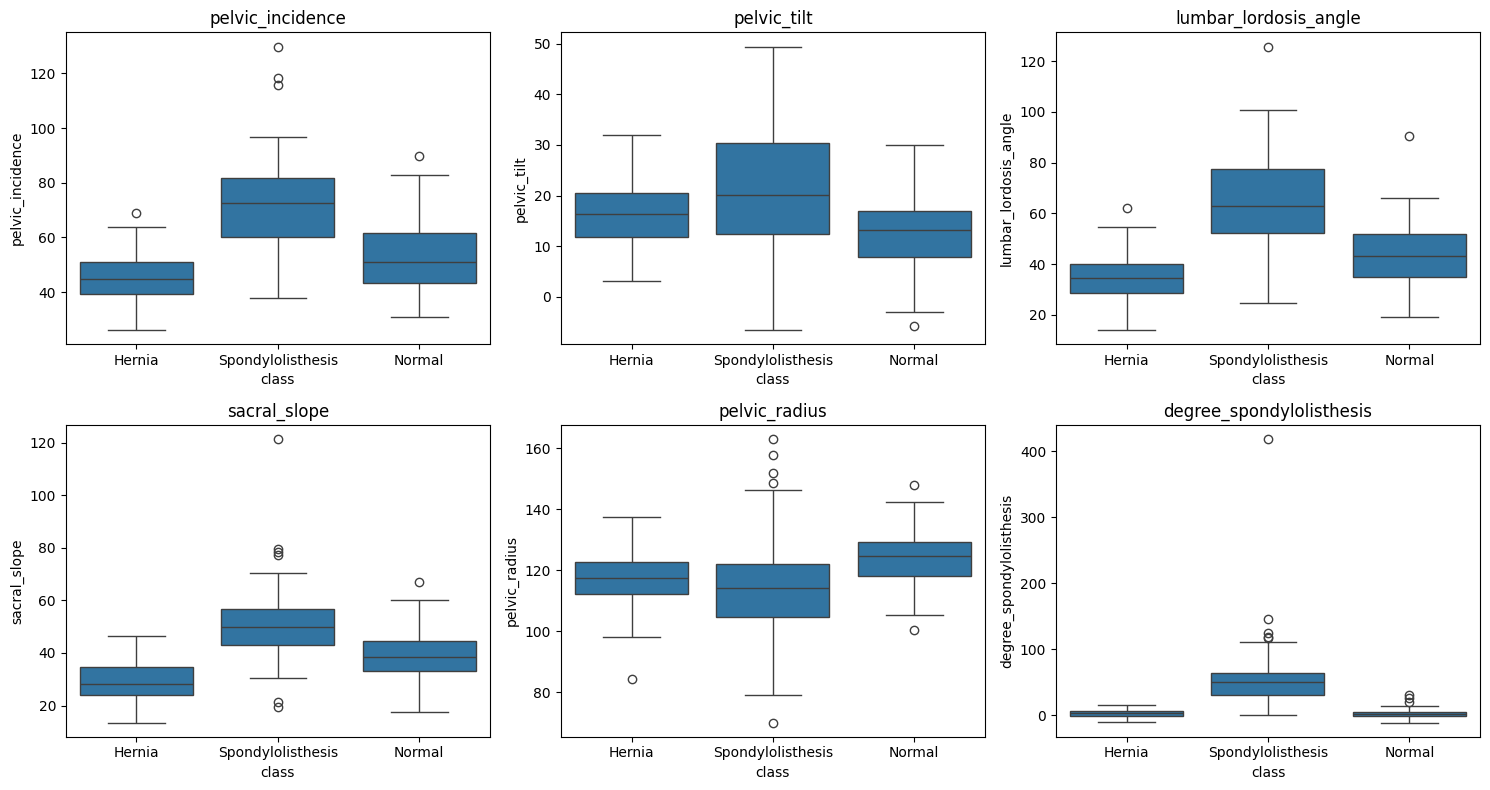

In [179]:
feature_cols = [c for c in train_df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=train_df, x='class', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Dividindo o dataset de treino: 80% treino e 20% teste

In [ ]:
X = train_df.drop(columns=['class'])
y = train_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Define que os dados serão divididos em 10 partes, mantendo a proporção das classes em cada parte.
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Definindo parâmetros para a validação cruzada

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 3, 4, 5, 6],
    'min_samples_leaf': [2, 3, 4, 5, 8],
    'ccp_alpha': [0.0, 0.0055, 0.0058, 0.0087],
    'class_weight': [None, 'balanced']
}

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00550509 0.00578035 0.00867052 0.00924855 0.00945875
 0.01109827 0.01114781 0.01256671 0.01801667 0.02987995 0.03243085
 0.06439853 0.34642826]


Grid Search

In [ ]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv_strategy,
    scoring='accuracy'
)

grid_search.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'ccp_alpha': [0.0, 0.0055, 0.0058, 0.0087],
                         'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, None],
                         'min_samples_leaf': [2, 3, 4, 5, 8],
                         'min_samples_split': [2, 3, 4, 5, 6]},
             scoring='accuracy')

In [ ]:
print('Melhores parâmetros:')
print(grid_search.best_params_)

print('Melhor accuracy na validação cruzada:')
print(grid_search.best_score_)

Melhores parâmetros:
{'ccp_alpha': 0.0055, 'class_weight': None, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}
Melhor accuracy na validação cruzada:
0.8619047619047621


In [ ]:
model = grid_search.best_estimator_

model.fit(X_train, y_train)
predictions = model.predict(X_test)

final_predictions = model.predict(test_df)

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

degree_spondylolisthesis    0.679144
sacral_slope                0.235423
pelvic_radius               0.063578
pelvic_tilt                 0.021854
pelvic_incidence            0.000000
lumbar_lordosis_angle       0.000000
dtype: float64


Resultados

In [ ]:
print('Accuracy:', accuracy_score(y_test, predictions))
print('F1:', f1_score(y_test, predictions, average='macro'))
print('Precision:', precision_score(y_test, predictions, average='macro'))
print('Recall:', recall_score(y_test, predictions, average='macro'))

Accuracy: 0.8636363636363636
F1: 0.8327220490250015
Precision: 0.8285714285714286
Recall: 0.8386243386243386


In [ ]:
scores = cross_val_score(grid_search.best_estimator_, X, y, cv=cv_strategy, scoring='accuracy')
print(scores.mean(), scores.std())

0.8619047619047621 0.061051240667117056


Matriz de confusão

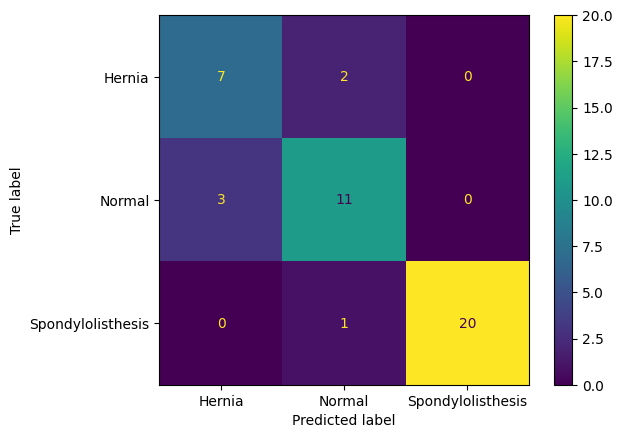

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

Criando arquivo de submissão

In [ ]:
def create_submission_file(predictions, test_df, submission_file_name="submission.csv"):
    submission_df = pd.DataFrame({'id': test_df.index, 'Target': predictions})
    submission_df.to_csv(submission_file_name, index=False)
    print(f"Submission file '{submission_file_name}' created successfully.")

In [ ]:
create_submission_file(final_predictions, test_df)

Submission file 'submission.csv' created successfully.
